In [1]:
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score,fbeta_score, roc_curve, roc_auc_score, precision_recall_curve,auc, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, SGDClassifier, Ridge, Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from itertools import cycle

In [2]:
df = pd.read_csv("C:\\Users\\User\\Documents\\ДЗ\\birulevo sentiment coded.csv")
df

,user,tweet,SENTIMENT,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,NaN,NaN,NaN,1.0,POSITIVE
1,BorisALV,в вост. #бирюлево на одну палатку с кошатиной ...,1,NaN,2.0,NEUTRAL
2,White_technolog,у районной управы собираются местные жители #б...,2,NaN,3.0,NEGATIVE
3,White_technolog,“@tvrain: тем временем конная полиция добралас...,2,NaN,NaN,NaN
4,White_technolog,в центре появились тощие прыщавые мужичонки с ...,3,NaN,NaN,NaN
...,...,...,...,...,...,...
1886,GraniTweet,наш корр @dmitryhorse ведет трансляцию из #бир...,2,NaN,NaN,NaN
1887,Fkontakte,“@gazetaru: #мид ответил на заявление германии...,2,NaN,NaN,NaN
1888,Fkontakte,“@rt_russian: #азербайджан'ские радикалы пригр...,3,NaN,NaN,NaN
1889,Fkontakte,“@rt_russian: эксклюзив: новые кадры задержани...,2,NaN,NaN,NaN


In [3]:
df.isna().sum()

user             1
tweet            1
SENTIMENT        1
Unnamed: 3    1891
Unnamed: 4    1888
Unnamed: 5    1888
dtype: int64

In [4]:
df=df[['user','tweet','SENTIMENT']]
df = df.dropna()
df

,user,tweet,SENTIMENT
1,BorisALV,в вост. #бирюлево на одну палатку с кошатиной ...,1
2,White_technolog,у районной управы собираются местные жители #б...,2
3,White_technolog,“@tvrain: тем временем конная полиция добралас...,2
4,White_technolog,в центре появились тощие прыщавые мужичонки с ...,3
5,White_technolog,"как пишет товарищ в смс, на площади революции ...",3
...,...,...,...
1886,GraniTweet,наш корр @dmitryhorse ведет трансляцию из #бир...,2
1887,Fkontakte,“@gazetaru: #мид ответил на заявление германии...,2
1888,Fkontakte,“@rt_russian: #азербайджан'ские радикалы пригр...,3
1889,Fkontakte,“@rt_russian: эксклюзив: новые кадры задержани...,2


In [5]:
tmp_df=df.groupby('SENTIMENT').agg('count')
tmp_df

,user,tweet
SENTIMENT,,
1,131,131
2,801,801
3,952,952
IRR,6,6


<Axes: xlabel='SENTIMENT', ylabel='tweet'>

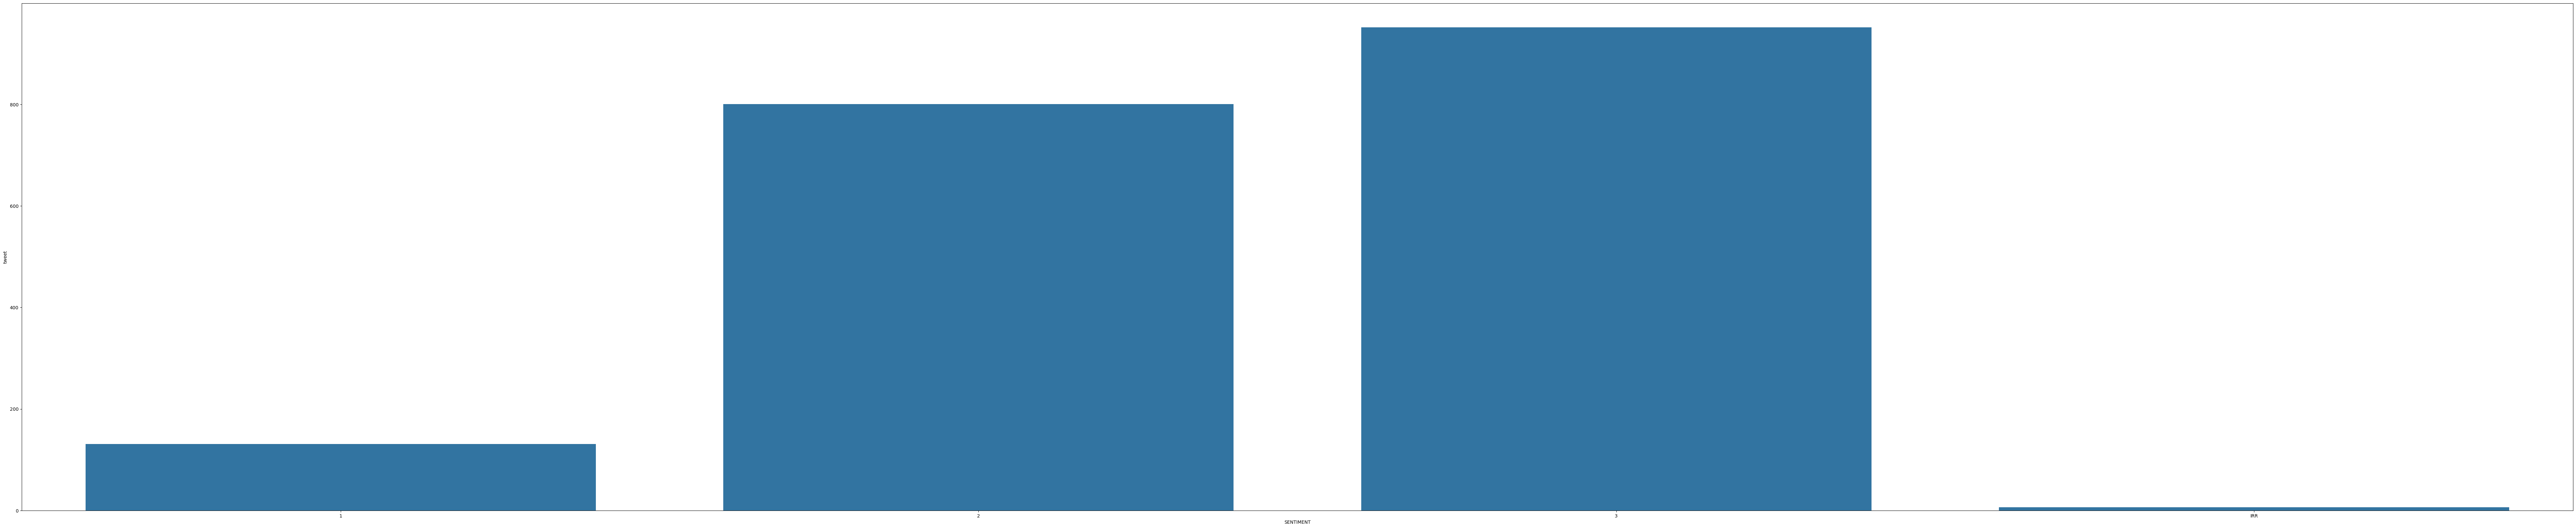

In [6]:
fig, ax = plt.subplots(figsize=(100, 20))
sns.barplot(x=tmp_df.index,y=tmp_df['tweet'],ax=ax)

In [7]:
##классы не сбалансированы

In [11]:
df = df[df['SENTIMENT'] != 'IRR'] ## В классе IRR  - всего 6 позиций -  недостаточно для корректного обучения модели


In [8]:
import re

In [9]:
## Приводим текст к нижнему регистру
df['tweet'] = df['tweet'].str.lower()
df

,user,tweet,SENTIMENT
1,BorisALV,в вост. #бирюлево на одну палатку с кошатиной ...,1
2,White_technolog,у районной управы собираются местные жители #б...,2
3,White_technolog,“@tvrain: тем временем конная полиция добралас...,2
4,White_technolog,в центре появились тощие прыщавые мужичонки с ...,3
5,White_technolog,"как пишет товарищ в смс, на площади революции ...",3
...,...,...,...
1886,GraniTweet,наш корр @dmitryhorse ведет трансляцию из #бир...,2
1887,Fkontakte,“@gazetaru: #мид ответил на заявление германии...,2
1888,Fkontakte,“@rt_russian: #азербайджан'ские радикалы пригр...,3
1889,Fkontakte,“@rt_russian: эксклюзив: новые кадры задержани...,2


In [10]:
## Убираем все знаки препинания
df['tweet'] = df['tweet'].str.replace(r'[^\w\s]', '', regex=True)
df

,user,tweet,SENTIMENT
1,BorisALV,в вост бирюлево на одну палатку с кошатиной ст...,1
2,White_technolog,у районной управы собираются местные жители би...,2
3,White_technolog,tvrain тем временем конная полиция добралась д...,2
4,White_technolog,в центре появились тощие прыщавые мужичонки с ...,3
5,White_technolog,как пишет товарищ в смс на площади революции ч...,3
...,...,...,...
1886,GraniTweet,наш корр dmitryhorse ведет трансляцию из бирюлево,2
1887,Fkontakte,gazetaru мид ответил на заявление германии о б...,2
1888,Fkontakte,rt_russian азербайджанские радикалы пригрозили...,3
1889,Fkontakte,rt_russian эксклюзив новые кадры задержания по...,2


In [12]:
##Преобразовать датасет в TF-IDF, поделить на треин-тест и спрогнозировать моделью SVM
X = df['tweet']
y = df['SENTIMENT']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    ##stratify=y  #т.к классы несбалансированны - не работал код поэтому пока закомментил
)

In [14]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words_ru = list(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,         
        stop_words=stop_words_ru,    
        ngram_range=(1, 2),      # униграммы + биграммы  (пары соседних слов)
        max_df=0.95,             # игнорировать слишком частые слова
        min_df=2,# игнорировать слишком редкие слова
        
    )),
    ('svm', LinearSVC(
        C=1.0,
        random_state =42,
        class_weight='balanced', # классы несбалансированы
        max_iter=10000
    ))
])

In [16]:
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6631299734748011

Classification report:
               precision    recall  f1-score   support

           1       0.25      0.31      0.28        26
           2       0.67      0.72      0.70       166
           3       0.73      0.66      0.69       185

    accuracy                           0.66       377
   macro avg       0.55      0.56      0.56       377
weighted avg       0.67      0.66      0.67       377



In [17]:
##Уровень 2 удалить слова используя стеммер Портера

In [18]:
'''from nltk.stem import PorterStemmer
Porter=PorterStemmer()
def stem_sentence(sentence):
    stemmed_words = []
    for word in sentence.split():
        stemmed_words.append(Porter.stem(word))
    return ' '.join(stemmed_words)
for text in X:
    print(stem_sentence(text))'''

"from nltk.stem import PorterStemmer\nPorter=PorterStemmer()\ndef stem_sentence(sentence):\n    stemmed_words = []\n    for word in sentence.split():\n        stemmed_words.append(Porter.stem(word))\n    return ' '.join(stemmed_words)\nfor text in X:\n    print(stem_sentence(text))"

In [19]:
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer('russian')
def stem_sentence(sentence):
    stemmed_words = []
    for word in sentence.split():
        stemmed_words.append(stemmer.stem(word))
    return ' '.join(stemmed_words)

In [20]:
for text in X:
    print(stem_sentence(text))

в вост бирюлев на одн палатк с кошатин стал меньш live
у район управ собира местн жител бирюлев live whitepower
tvrain тем времен кон полиц добра до бирюлев pictwittercomblrf074rmj бирюлев live бунт
в центр появ тощ прыщав мужичонк с красн повязк дружинник live бунт москв бирюлев
как пишет товарищ в смс на площад революц черн черн в смысл орд черножоп live бирюлев москв
на стм пушкинск 6 полицейск с дубинк и каск один черножоп москв live бирюлев
в вост бирюлев на одн палатк с кошатин стал меньш live
amnesty international массов задержан мигрант в москв эт нарушен прав httpamnestyorgrunode2628 новост сми бирюлев навальн
рт молн зомб в бирюлев напада на всех он повсюд спорт росс гринпис novosti russia news путин pictwittercomeiojqusphz
бирюлевск убийц зейнал рвет на свобод httpbitly16jkdua бирюлев москв moscow russia news
в бирюлев найд убит гражданин узбекиста httpbitly17syck9 news
зейнал в разговор с полицейск призна вин мвд news бирюлев
овощебаз в бирюлев закрыва в рамк уголовн дел ht

In [21]:
# Сетка параметров
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],          # униграммы vs униграммы+биграммы
    'tfidf__max_df': [0.9, 0.95],                    # доля документов, выше которой слово игнорируется
    'tfidf__min_df': [1, 2, 5],                     # минимальная частота документа
    'svm__C': [0.1, 1.0, 10.0]                      # сила регуляризации SVM
}

# GridSearch
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,                                           # 5 фолдов кросс‑валидации
    scoring='f1_macro',                             # хорошо для несбалансированных классов (как в sentiment)
    n_jobs=-1,                                      # использовать все ядра
    verbose=1                                       # показывать прогресс
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший CV score (F1 macro):", grid_search.best_score_)

## macro f1- среднее F1 по классам без учёта их размера
## weighted -среднее с весами по количеству объектов класса 
## micro -агрегирует TP, FP, FN по всем классам и считает единый F1 


# Оценка на тесте
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("\nTest F1 macro:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры: {'svm__C': 0.1, 'tfidf__max_df': 0.95, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Лучший CV score (F1 macro): 0.4965450355595856

Test F1 macro: 0.5665778929087716
              precision    recall  f1-score   support

           1       0.62      0.19      0.29        26
           2       0.68      0.73      0.70       166
           3       0.69      0.71      0.70       185

    accuracy                           0.68       377
   macro avg       0.67      0.54      0.57       377
weighted avg       0.68      0.68      0.67       377



In [22]:
##Уровень 3

In [23]:
##Использовать лемматизатор pymorphy вместо стемминга

In [24]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

def stem_morph_sentence(sentence):
    stemmed_morph_words = []
    for word in sentence.split():
        stemmed_morph_words.append((morph.parse(word)[0]).normal_form)
    return ' '.join(stemmed_morph_words)
lemm_x = X.apply(stem_morph_sentence)
lemm_x

1       в вост бирюлёво на один палатка с кошатина ста...
2       у районный управа собираться местный житель би...
3       tvrain тем время конный полиция добраться до б...
4       в центр появиться тощий прыщавый мужичонка с к...
5       как писать товарищ в смс на площадь революция ...
                              ...                        
1886    наш корра dmitryhorse вести трансляция из бирю...
1887    gazetaru мид ответить на заявление германия о ...
1888    rt_russian азербайджанский радикал пригрозить ...
1889    rt_russian эксклюзив новый кадр задержание под...
1890    предполагать убийца егор щербаков в бирюлёво о...
Name: tweet, Length: 1884, dtype: object

In [57]:
for text in X:
    print(stem_morph_sentence(text))

в вост бирюлёво на один палатка с кошатина стать маленький live
у районный управа собираться местный житель бирюлёво live whitepower
tvrain тем время конный полиция добраться до бирюлев pictwittercomblrf074rmj бирюлёво live бунт
в центр появиться тощий прыщавый мужичонка с красный повязка дружинник live бунт москва бирюлёво
как писать товарищ в смс на площадь революция чёрный черно в смысл орда черножопый live бирюлёво мос
на стм пушкинский 6 полицейский с дубинка и каска один черножопый москва live бирюлёво
в вост бирюлёво на один палатка с кошатина стать маленький live
amnesty international массовый задержание мигрант в москва это нарушение право httpamnestyorgrunode2
рт молния зомби в бирюлёво нападать на весь они повсюду спорт россия гринпис novosti russia news пут
бирюлёвский убийца зейнал рваться на свобода httpbitly16jkdua бирюлёво москва moscow russia news
в бирюлёво найти убитый гражданин узбекистан httpbitly17syck9 news
зейнал в разговор с полицейский признать вина мвд news б

In [26]:
import nltk
nltk.download('punkt_tab')
nltk.download("stopwords")
russian_stopwords = stopwords.words("russian")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
def preprocess_text(text):
    #   нижний регистр
    text = str(text).lower()
    # Оставляем только кириллицу и пробелы
    text = re.sub(r'[^а-яё\s]', ' ', text)
    # Токенизация
    tokens = word_tokenize(text, language='russian')
    # Лемматизация 
    lemmas = [morph.parse(t)[0].normal_form for t in tokens if t]
    # Удаляем слишком короткие токены и стоп-слова 
    russian_stopwords = stopwords.words("russian")
    cleaned = [t for t in lemmas if len(t) > 2 and t not in russian_stopwords]
    return cleaned

df['tokens'] = df['tweet'].apply(preprocess_text)

C:\Users\User\AppData\Local\Temp\ipykernel_2384\3325013828.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokens'] = df['tweet'].apply(preprocess_text)


In [28]:
##Использовать word2vec вместо tf-idf.

In [29]:
import gensim.downloader as api
'''model_w2v = api.load("word2vec-ruscorpora-300")'''
model_w2v = api.load("glove-twitter-100")


In [30]:
from gensim.models import Word2Vec

In [31]:
'''
model_w2v = Word2Vec(sentences=X, vector_size=100, window=5, min_count=1,)
def doc_vector(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if len(vectors) == 0:
        # если ни одно слово не попало в словарь — нулевой вектор
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.vstack(X.apply(lambda t: doc_vector(t, model_w2v)))'''

'\nmodel_w2v = Word2Vec(sentences=X, vector_size=100, window=5, min_count=1,)\ndef doc_vector(tokens, model):\n    vectors = [model.wv[t] for t in tokens if t in model.wv]\n    if len(vectors) == 0:\n        # если ни одно слово не попало в словарь — нулевой вектор\n        return np.zeros(model.vector_size)\n    return np.mean(vectors, axis=0)\n\nX_w2v = np.vstack(X.apply(lambda t: doc_vector(t, model_w2v)))'

In [32]:
#  Функция усреднения векторов документа
def doc_vector(tokens, model):
    vectors = [model[t] for t in tokens if t in model]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)
    
X_w2v = np.vstack([doc_vector(toks, model_w2v) for toks in df['tokens']])
X_w2v = X_w2v.astype(np.float64)
X_w2v = np.nan_to_num(X_w2v)

In [33]:
X_w2v ## матрица (n_samples, vector_size)

array([[-0.22059925, -0.11474474, -0.42166424, ..., -0.67615998,
         0.26476249,  0.12710124],
       [-0.25085881,  0.33253622, -0.23178139, ..., -0.19325802,
         0.05493798,  0.30506361],
       [-0.11401341, -0.0835398 , -0.43365496, ..., -0.51154405,
         0.115108  ,  0.0225614 ],
       ...,
       [-0.06703956, -0.08621529, -0.62790811, ..., -0.34319857,
         0.22445284, -0.15815304],
       [ 0.19243038,  0.0416635 , -0.61773336, ..., -0.36950874,
         0.218253  ,  0.19207437],
       [ 0.28582716,  0.19925684, -0.46175948, ..., -0.16230084,
         0.09369001,  0.35915908]], shape=(1884, 100))

In [34]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_w2v, y,
    test_size=0.2,
    random_state=42
)

In [36]:
##

In [37]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


## Будем сравнивать модели SVC, СatBoost, и логистической регрессии

In [38]:
from catboost import CatBoostClassifier

In [39]:
model_cat = CatBoostClassifier(
    iterations=200,
    depth=5,
    learning_rate=0.05,
    loss_function='MultiClass',          
    verbose=0,                           
    random_seed=42,
    auto_class_weights='Balanced'              
)

In [40]:
param_grid2 = {
    'depth': [3, 5],
    'learning_rate': [0.01,0.05, 0.1],
    'iterations': [200, 300]
}
grid = GridSearchCV(
    model_cat,
    param_grid2,
    cv=5,
    scoring='f1_macro',
    n_jobs=2,
    verbose=1, 
)

grid.fit(X_train2, y_train2)

print("Лучшие параметры:", grid.best_params_)
print("Лучший CV F1 macro:", grid.best_score_)

best_model = grid.best_estimator_
y_pred3 = best_model.predict(X_test2)


print("\nTest F1 macro:", f1_score(y_test2, y_pred3, average='macro')) 
print(classification_report(y_test2, y_pred3))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Лучшие параметры: {'depth': 5, 'iterations': 200, 'learning_rate': 0.1}
Лучший CV F1 macro: 0.506172691541347

Test F1 macro: 0.5685248151889803
              precision    recall  f1-score   support

           1       0.40      0.23      0.29        26
           2       0.69      0.71      0.70       166
           3       0.71      0.72      0.71       185

    accuracy                           0.68       377
   macro avg       0.60      0.56      0.57       377
weighted avg       0.68      0.68      0.68       377



In [41]:
from sklearn.metrics import log_loss, roc_auc_score, roc_curve

In [42]:
from sklearn.svm import SVC
svc_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
model_cat.fit(X_train2, y_train2)
svc_model.fit(X_train2, y_train2)
y_pred_proba_svc = svc_model.predict_proba(X_test2)
y_pred_proba_cat = model_cat.predict_proba(X_test2)

In [43]:
model_reg = LogisticRegression(
    C=1,                # сила регуляризации (меньше = сильнее регуляризация)
    penalty='l2',         # тип регуляризации
    solver='lbfgs',       # решатель
    max_iter=1000,        # максимум итераций
    random_state=42
)
model_reg.fit(X_train2, y_train2)

y_pred_logistic = model_reg.predict(X_test2)
y_pred_proba_reg = model_reg.predict_proba(X_test2)

print("Accuracy:", accuracy_score(y_test, y_pred_logistic))

Accuracy: 0.6604774535809018


In [60]:
from sklearn.preprocessing import label_binarize
classes = sorted(np.unique(y))
y_test_bin = label_binarize(y_test, classes=classes) ##  превращает категориальные метки классов в бинарную  матрицу
n_classes = y_test_bin.shape[1]

In [62]:
## logloss
logloss_cat = log_loss(y_test2, y_pred_proba_cat)
logloss_svc = log_loss(y_test2, y_pred_proba_svc)
logloss_reg = log_loss(y_test2, y_pred_proba_reg)
print(f"CatBoost LogLoss: {logloss_cat:.4f}")
print(f"SVC LogLoss:       {logloss_svc:.4f}")
print(f"reg LogLoss:       {logloss_reg:.4f}")

CatBoost LogLoss: 0.8077
SVC LogLoss:       0.7345
reg LogLoss:       0.7804


In [46]:
def compute_metrics_per_class(y_true_bin, y_score):
    auc_per_class = []
    ap_per_class = []
    for i in range(y_true_bin.shape[1]):
        auc_val = roc_auc_score(y_true_bin[:, i], y_score[:, i])
        ap_val = average_precision_score(y_true_bin[:, i], y_score[:, i])
        auc_per_class.append(auc_val)
        ap_per_class.append(ap_val)
    return auc_per_class, ap_per_class

auc_cat, ap_cat = compute_metrics_per_class(y_test_bin, y_pred_proba_cat)
auc_svc, ap_svc = compute_metrics_per_class(y_test_bin, y_pred_proba_svc)
auc_reg, ap_reg = compute_metrics_per_class(y_test_bin, y_pred_proba_reg)



In [47]:
print("\n--- CatBoost ---")
print(f"ROC-AUC (macro): {np.mean(auc_cat):.4f}")
print(f"AP (macro):      {np.mean(ap_cat):.4f}")
for i, (a, p) in enumerate(zip(auc_cat, ap_cat)):
    print(f"Class {classes[i]}: ROC-AUC={a:.4f}, AP={p:.4f}")

print("\n--- SVC ---")
print(f"ROC-AUC (macro): {np.mean(auc_svc):.4f}")
print(f"AP (macro):      {np.mean(ap_svc):.4f}")
for i, (a, p) in enumerate(zip(auc_svc, ap_svc)):
    print(f"Class {classes[i]}: ROC-AUC={a:.4f}, AP={p:.4f}")

print("\n--- Logistic regression ---")
print(f"ROC-AUC (macro): {np.mean(auc_reg):.4f}")
print(f"AP (macro):      {np.mean(ap_reg):.4f}")
for i, (a, p) in enumerate(zip(auc_reg, ap_reg)):
    print(f"Class {classes[i]}: ROC-AUC={a:.4f}, AP={p:.4f}")    


--- CatBoost ---
ROC-AUC (macro): 0.7642
AP (macro):      0.6219
Class 1: ROC-AUC=0.7016, AP=0.3257
Class 2: ROC-AUC=0.8132, AP=0.7727
Class 3: ROC-AUC=0.7779, AP=0.7674

--- SVC ---
ROC-AUC (macro): 0.7647
AP (macro):      0.5769
Class 1: ROC-AUC=0.7041, AP=0.1876
Class 2: ROC-AUC=0.8089, AP=0.7767
Class 3: ROC-AUC=0.7810, AP=0.7665

--- Logistic regression ---
ROC-AUC (macro): 0.7330
AP (macro):      0.5307
Class 1: ROC-AUC=0.6867, AP=0.1579
Class 2: ROC-AUC=0.7732, AP=0.7092
Class 3: ROC-AUC=0.7392, AP=0.7251


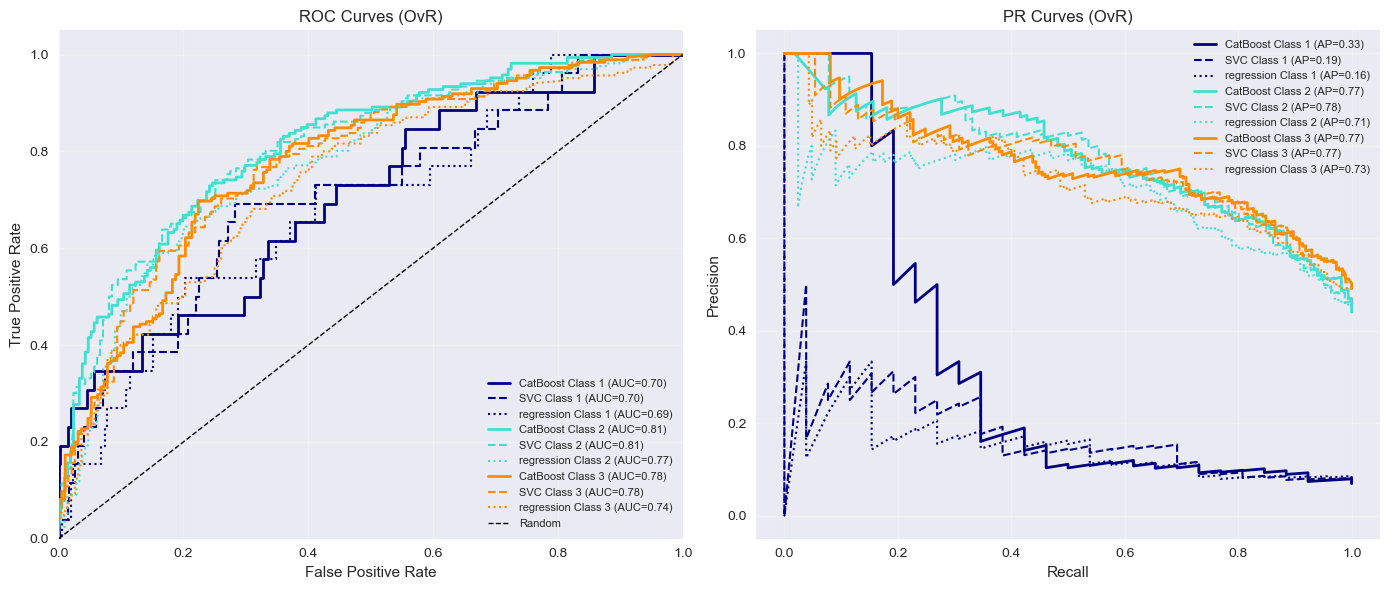

In [48]:
##AP и PR-кривые
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])

# ROC
ax = axs[0]
for i, color in zip(range(n_classes), colors):
    fpr_cat, tpr_cat, _ = roc_curve(y_test_bin[:, i], y_pred_proba_cat[:, i])
    ax.plot(fpr_cat, tpr_cat, color=color, lw=2,
            label=f'CatBoost Class {classes[i]} (AUC={auc_cat[i]:.2f})')

    fpr_svc, tpr_svc, _ = roc_curve(y_test_bin[:, i], y_pred_proba_svc[:, i])
    ax.plot(fpr_svc, tpr_svc, color=color, lw=1.5, linestyle='--',
            label=f'SVC Class {classes[i]} (AUC={auc_svc[i]:.2f})')

    fpr_reg, tpr_reg, _ = roc_curve(y_test_bin[:, i], y_pred_proba_reg[:, i])
    ax.plot(fpr_reg, tpr_reg, color=color, lw=1.5, linestyle=':',
            label=f'regression Class {classes[i]} (AUC={auc_reg[i]:.2f})')
    
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (OvR)')
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)

# PR
ax = axs[1]
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])
for i, color in zip(range(n_classes), colors):
    prec_cat, rec_cat, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_cat[:, i])
    ax.plot(rec_cat, prec_cat, color=color, lw=2,
            label=f'CatBoost Class {classes[i]} (AP={ap_cat[i]:.2f})')

    prec_svc, rec_svc, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_svc[:, i])
    ax.plot(rec_svc, prec_svc, color=color, lw=1.5, linestyle='--',
            label=f'SVC Class {classes[i]} (AP={ap_svc[i]:.2f})')

    prec_reg, rec_reg, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_reg[:, i])
    ax.plot(rec_reg, prec_reg, color=color, lw=1.5, linestyle=':',
            label=f'regression Class {classes[i]} (AP={ap_reg[i]:.2f})')    

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curves (OvR)')
ax.legend(loc="best", fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
y_pred_cat = np.argmax(y_pred_proba_cat, axis=1)
y_pred_svc = np.argmax(y_pred_proba_svc, axis=1)
y_pred_reg = np.argmax(y_pred_proba_reg, axis=1)

In [50]:
y_pred_cat_mapped = np.array([classes[i] for i in y_pred_cat])
y_pred_svc_mapped = np.array([classes[i] for i in y_pred_svc])
y_pred_reg_mapped = np.array([classes[i] for i in y_pred_reg])


cm_cat = confusion_matrix(y_test2, y_pred_cat_mapped, labels=classes)
cm_svc = confusion_matrix(y_test2, y_pred_svc_mapped, labels=classes)
cm_reg = confusion_matrix(y_test2, y_pred_reg_mapped, labels=classes)

In [51]:
classes

['1', '2', '3']

In [52]:
print("\nConfusion Matrix (CatBoost, counts):\n", cm_cat)
print("\nConfusion Matrix (SVC, counts):\n", cm_svc)
print("\nConfusion Matrix (regression, counts):\n", cm_reg)


Confusion Matrix (CatBoost, counts):
 [[  6   8  12]
 [  5 120  41]
 [  4  43 138]]

Confusion Matrix (SVC, counts):
 [[  1   8  17]
 [  0 117  49]
 [  2  41 142]]

Confusion Matrix (regression, counts):
 [[  1   7  18]
 [  1 114  51]
 [  1  50 134]]


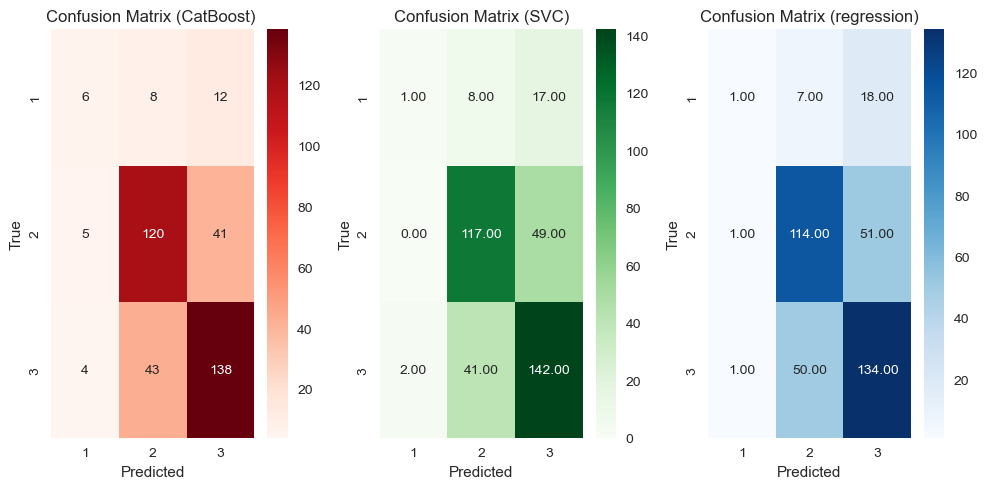

In [61]:
# Confusion Matrix CatBoost 

fig, axs = plt.subplots(1, 3, figsize=(10, 5), squeeze=False)
ax = axs[0, 0]
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Reds',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (CatBoost) ')

# Confusion Matrix SVC 
ax = axs[0, 1]
sns.heatmap(cm_svc, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (SVC)')

# Confusion Matrix regression
ax = axs[0, 2]
sns.heatmap(cm_reg, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (regression)')
plt.tight_layout()
plt.show()

##Метрики и матрицы ошибок показывают что лучше всего предсгазывает модель Catboost.Чуть хуже справляется SVM. Модель логистической регрессии справляется сильно хуже первых двух. 
## значение AP  покаывает что бустинг обгоняет SVM за счет лучшего предсказывания 1-ого класса ( хоть и все модели предсказывают 1 класс довльно плохо, но это логично т.к в нем сильно меньше значений чем в  2 и 3 классах)